## 1. Ratings Distribution Comparison
Generate a grid of observed vs. model predicted ratings distribution charts horizontally.

- **Grid Structure**: 2 rows x n columns (where n is the number of datasets).
- **Row 1**: Observed ratings distribution (discrete bar chart) from the test fold (the last fold *k* of the time series cross validation).
- **Row 2**: Model predicted ratings distribution (continuous density plot with KDE) from the corresponding *k*-th fold prediction file `eval_error_conf-{k}.csv`.

In [1]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({                                                                                  
        "font.size": 20,            # General text font size                                               
        "axes.labelsize": 20,       # X and Y axis labels font size                                        
        "axes.titlesize": 22,       # Axes titles font size                                                
        "xtick.labelsize": 16,      # X-axis tick labels font size                                         
        "ytick.labelsize": 16,      # Y-axis tick labels font size                                         
        "legend.fontsize": 16,      # Legend font size                                                     
        "figure.titlesize": 20      # Main figure title font size                                          
    })


In [2]:
runs_dir = "../runs"

models = ['mf_wasserstein', 'cpmf_wasserstein', 'dropout_wasserstein', 'lbd_wasserstein', 'ordrec_wasserstein', 'prlightgcn_wasserstein']
datasets = ['ml-1m']

metrics = [
    ('rmse', 'RMSE', 'lower is better'),
    ('mNDCG@10', 'NDCG@10', 'higher is better'),
    ('MAP@10', 'MAP@10', 'higher is better'),
    ('kl_diverence', 'KL Divergence', 'lower is better')
]

For dataset ml-1m, found common folds: [0, 1, 2, 3, 4]


Successfully saved prediction comparison plot to: ratings-distribution-comparison.png


Successfully saved observed ratings distribution to: observed-ratings-distribution.png


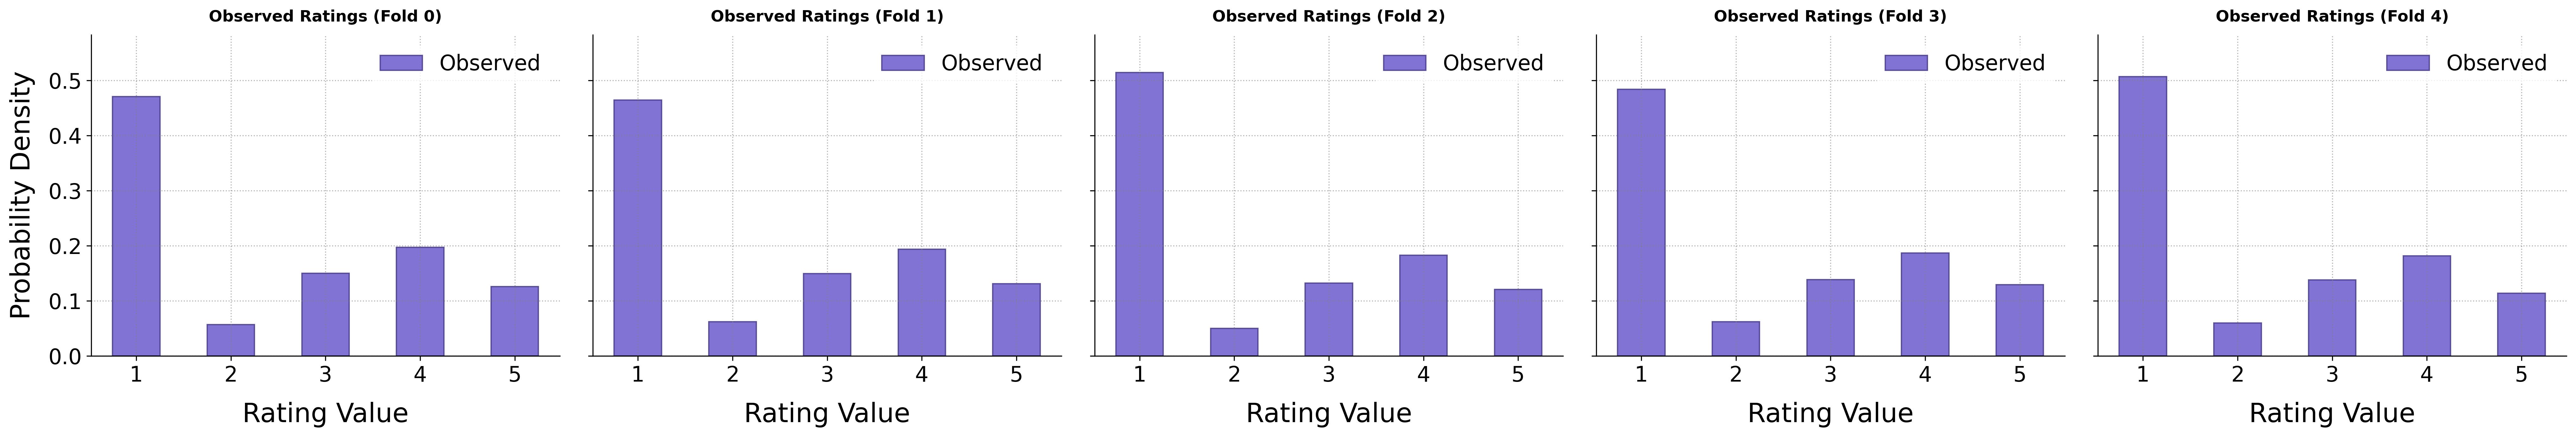

No rating distribution data available to plot.


In [5]:
# 1. Gather ratings distribution data for all datasets and common folds
datasets_data = []

# First, find the available folds for each model/dataset combination
# so we can choose common folds for consistency.
available_folds = {}

for db in datasets:
    available_folds[db] = {}
    for m in models:
        m_base = m.replace('_wasserstein', '')
        
        # We need to find the Wasserstein model folders with lambda = 1
        pattern = os.path.join(runs_dir, f"{db}-{m_base}_wasserstein-*")
        folders = glob.glob(pattern)
        
        folds_set = set()
        for f in folders:
            name = os.path.basename(f)
            prefix = f"{db}-{m_base}_wasserstein-"
            if not name.startswith(prefix):
                continue
            suffix = name[len(prefix):]
            parts = suffix.split('-')
            
            # parts can be [fold] or [lambda, fold]
            if len(parts) == 1:
                try:
                    fold = int(parts[0])
                    folds_set.add(fold)
                except ValueError:
                    continue
            elif len(parts) == 2:
                lambda_val = parts[0]
                try:
                    fold = int(parts[1])
                    if lambda_val in ("1", "1.0"):
                        folds_set.add(fold)
                except ValueError:
                    continue
                    
        # Check base folders for each of these folds
        valid_folds = set()
        for fold in folds_set:
            base_folder = os.path.join(runs_dir, f"{db}-{m_base}-{fold}")
            if not os.path.exists(base_folder):
                # Fallback check
                fallback_pattern = os.path.join(runs_dir, f"{db}-{m_base}_wasserstein-*-{fold}")
                fallback_folders = glob.glob(fallback_pattern)
                has_fallback = False
                for f in fallback_folders:
                    name = os.path.basename(f)
                    prefix = f"{db}-{m_base}_wasserstein-"
                    suffix = name[len(prefix):]
                    parts = suffix.split('-')
                    if len(parts) == 2:
                        try:
                            lambda_val = float(parts[0])
                            if lambda_val != 1.0:
                                has_fallback = True
                                break
                        except ValueError:
                            continue
                if has_fallback:
                    valid_folds.add(fold)
            else:
                valid_folds.add(fold)
                
        available_folds[db][m] = valid_folds

for db in datasets:
    # Find the maximum common folds across all selected models for this dataset
    sets = list(available_folds[db].values())
    if not sets:
        print(f"No valid models found for dataset: {db}")
        continue
        
    common = set.intersection(*sets)
    if not common:
        print(f"No common folds found across models for dataset: {db}")
        continue
        
    sorted_folds = sorted(list(common))
    print(f"For dataset {db}, found common folds: {sorted_folds}")
    
    num_folds = len(sorted_folds)
    num_models = len(models)
    
    # Create a grid where rows represent folds in ascending order, and columns represent models
    fig, axes = plt.subplots(num_folds, num_models, figsize=(5.5 * num_models, 4.5 * num_folds), dpi=300, sharex=True, sharey=False)
    
    # Ensure axes is a 2D array even if it is 1x1, 1D, etc.
    if num_folds == 1 and num_models == 1:
        axes = np.array([[axes]])
    elif num_folds == 1:
        axes = np.expand_dims(axes, axis=0)
    elif num_models == 1:
        axes = np.expand_dims(axes, axis=1)
        
    observed_data = {}
    
    for i, fold in enumerate(sorted_folds):
        for j, m in enumerate(models):
            m_base = m.replace('_wasserstein', '')
            
            # Find the Wasserstein model folder for the fold
            pattern = os.path.join(runs_dir, f"{db}-{m_base}_wasserstein-*")
            folders = glob.glob(pattern)
            
            selected_wass_folder = None
            for f in folders:
                name = os.path.basename(f)
                prefix = f"{db}-{m_base}_wasserstein-"
                if not name.startswith(prefix):
                    continue
                suffix = name[len(prefix):]
                parts = suffix.split('-')
                
                if len(parts) == 1:
                    try:
                        f_val = int(parts[0])
                        if f_val == fold:
                            selected_wass_folder = f
                            break
                    except ValueError:
                        continue
                elif len(parts) == 2:
                    lambda_val = parts[0]
                    try:
                        f_val = int(parts[1])
                        if f_val == fold and lambda_val in ("1", "1.0"):
                            selected_wass_folder = f
                            break
                    except ValueError:
                        continue
                        
            if not selected_wass_folder:
                print(f"Skipping: lambda=1 Wasserstein folder not found for model {m_base} at fold {fold}")
                continue
                
            # Path to Wasserstein prediction CSV
            wass_csv = os.path.join(selected_wass_folder, f"eval_error_conf-{fold}.csv")
            if not os.path.exists(wass_csv):
                csv_files = glob.glob(os.path.join(selected_wass_folder, "eval_error_conf-*.csv"))
                if csv_files:
                    wass_csv = csv_files[0]
                else:
                    print(f"Skipping: eval_error_conf not found in: {selected_wass_folder}")
                    continue
                    
            # Find corresponding non-Wasserstein folder
            base_folder = os.path.join(runs_dir, f"{db}-{m_base}-{fold}")
            
            # Fallback to smallest regularization folder if not found
            if not os.path.exists(base_folder):
                fallback_pattern = os.path.join(runs_dir, f"{db}-{m_base}_wasserstein-*-{fold}")
                fallback_folders = glob.glob(fallback_pattern)
                if fallback_folders:
                    candidates = []
                    for f in fallback_folders:
                        name = os.path.basename(f)
                        prefix = f"{db}-{m_base}_wasserstein-"
                        suffix = name[len(prefix):]
                        parts = suffix.split('-')
                        if len(parts) == 2:
                            try:
                                lambda_val = float(parts[0])
                                if lambda_val != 1.0:
                                    candidates.append((lambda_val, f))
                            except ValueError:
                                continue
                    if candidates:
                        candidates.sort()
                        base_folder = candidates[0][1]
                        
            if not os.path.exists(base_folder):
                print(f"Skipping: base folder does not exist: {base_folder}")
                continue
                
            base_csv = os.path.join(base_folder, f"eval_error_conf-{fold}.csv")
            if not os.path.exists(base_csv):
                csv_files = glob.glob(os.path.join(base_folder, "eval_error_conf-*.csv"))
                if csv_files:
                    base_csv = csv_files[0]
                else:
                    print(f"Skipping: eval_error_conf not found in: {base_folder}")
                    continue
                    
            # Read the ratings
            df_base = pd.read_csv(base_csv)
            df_wass = pd.read_csv(wass_csv)
            
            pred_base = df_base['r_pred'].values
            pred_wass = df_wass['r_pred'].values
            obs = df_base['rating'].values
            
            if fold not in observed_data:
                observed_data[fold] = obs
                
            ax = axes[i, j]
            
            # Check range of predictions to avoid binwidth error on very narrow spans (e.g. CPMF)
            pred_range = max(np.max(pred_base) - np.min(pred_base), np.max(pred_wass) - np.min(pred_wass))
            if pred_range < 0.5:
                sns.histplot(
                    pred_base, 
                    ax=ax, 
                    color='RoyalBlue', 
                    kde=True, 
                    stat='density', 
                    bins=10, 
                    alpha=0.4, 
                    edgecolor='blue', 
                    label='Without Wass.'
                )
                sns.histplot(
                    pred_wass, 
                    ax=ax, 
                    color='Tomato', 
                    kde=True, 
                    stat='density', 
                    bins=10, 
                    alpha=0.5, 
                    edgecolor='chocolate', 
                    label='With Wass. (λ=1)'
                )
            else:
                sns.histplot(
                    pred_base, 
                    ax=ax, 
                    color='RoyalBlue', 
                    kde=True, 
                    stat='density', 
                    binwidth=0.5,
                    alpha=0.4, 
                    edgecolor='blue', 
                    label='Without Wass.'
                )
                sns.histplot(
                    pred_wass, 
                    ax=ax, 
                    color='Tomato', 
                    kde=True, 
                    stat='density', 
                    binwidth=0.5,
                    alpha=0.5, 
                    edgecolor='chocolate', 
                    label='With Wass. (λ=1)'
                )
            
            ax.set_title(f"{m_base.upper()} (Fold {fold})", fontsize=11, fontweight='bold', pad=8)
            ax.set_xlim(0.5, 5.5)
            ax.grid(True, linestyle=':', alpha=0.6, color='gray')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Y-labels on the first column only
            if j == 0:
                ax.set_ylabel("Probability Density", labelpad=10)
            else:
                ax.set_ylabel("")
                
            # X-labels on the bottom row only
            if i == num_folds - 1:
                ax.set_xlabel("Rating Value", labelpad=10)
            else:
                ax.set_xlabel("")
                
            ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='none')

    plt.tight_layout()
    filename_dist = "ratings-distribution-comparison.png"
    plt.savefig(filename_dist, bbox_inches='tight', dpi=300)
    print(f"Successfully saved prediction comparison plot to: {filename_dist}")
    plt.show()

    # 3. Plot Observed Ratings separately in a horizontal grid (1 row x num_folds columns)
    if observed_data:
        fig_obs, axes_obs = plt.subplots(1, num_folds, figsize=(5.5 * num_folds, 5.0), dpi=300, sharey=True)
        if num_folds == 1:
            axes_obs = [axes_obs]
            
        for i, fold in enumerate(sorted_folds):
            if fold in observed_data:
                obs = observed_data[fold]
                ax_obs = axes_obs[i]
                ratings_val, counts = np.unique(obs, return_counts=True)
                probs = counts / len(obs)
                
                ax_obs.bar(ratings_val, probs, color='SlateBlue', alpha=0.85, edgecolor='darkslateblue', width=0.5, label='Observed')
                ax_obs.set_title(f"Observed Ratings (Fold {fold})", fontsize=12, fontweight='bold', pad=10)
                ax_obs.set_xlabel("Rating Value", labelpad=12)
                if i == 0:
                    ax_obs.set_ylabel("Probability Density", labelpad=10)
                ax_obs.set_ylim(0, max(probs) * 1.15)
                ax_obs.grid(True, linestyle=':', alpha=0.6, color='gray')
                ax_obs.spines['top'].set_visible(False)
                ax_obs.spines['right'].set_visible(False)
                ax_obs.legend(loc='best', frameon=True, facecolor='white', edgecolor='none')
                
        plt.tight_layout()
        filename_obs = "observed-ratings-distribution.png"
        plt.savefig(filename_obs, bbox_inches='tight', dpi=300)
        print(f"Successfully saved observed ratings distribution to: {filename_obs}")
        plt.show()
else:
    print("No rating distribution data available to plot.")